# Unit14 Example 03 - 多種操作溫度對反應轉化率的影響 — 單因子 ANOVA

本 Notebook 以**五種不同反應溫度下的轉化率數據**為例，示範完整的單因子 ANOVA 分析流程：前提檢定（常態性與變異數齊一性）、F 檢定、手動 ANOVA 表建構、Tukey HSD 多重比較，以及 Kruskal-Wallis 無母數替代方案。

## 目標
- 使用 `scipy.stats.shapiro()` 與 `scipy.stats.levene()` 確認 ANOVA 前提
- 使用 `scipy.stats.f_oneway()` 執行單因子 ANOVA
- 手動建構 ANOVA 表，加深對 $F = \frac{MS_{between}}{MS_{within}}$ 的理解
- 簡介 Tukey HSD 多重比較方法（`statsmodels.pairwise_tukeyhsd`）
- 使用 `scipy.stats.kruskal()` 執行 Kruskal-Wallis 無母數檢定
- 繪製箱型圖（含顯著差異標記）與殘差常態 Q-Q 圖

---
### 0. 環境設定

In [17]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit14_Example_03'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit14'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit14
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_03
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_03\figs


---
### 1. 載入套件

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("套件載入完成:")
print(f"  numpy       version: {np.__version__}")
import scipy
print(f"  scipy       version: {scipy.__version__}")
import matplotlib
print(f"  matplotlib  version: {matplotlib.__version__}")
import statsmodels
print(f"  statsmodels version: {statsmodels.__version__}")

套件載入完成:
  numpy       version: 1.23.5
  scipy       version: 1.15.2
  matplotlib  version: 3.10.8
  statsmodels version: 0.14.6


---
### 2. 問題描述與模擬數據

**問題背景：** 在五種不同反應溫度 (300, 320, 340, 360, 380°C) 下各進行 8 次批次反應，量測轉化率 $X_A$ (%)，以 ANOVA 判斷溫度是否顯著影響轉化率。

| 溫度 (°C) | 真實均值 $\mu$ (%) | 組內標準差 $\sigma$ | 樣本數 $n$ |
|-----------|-------------------|--------------------|-----------| 
| 300 | 62.0 | 3.0 | 8 |
| 320 | 66.0 | 3.0 | 8 |
| 340 | 71.0 | 3.0 | 8 |
| 360 | 75.0 | 3.0 | 8 |
| 380 | 79.0 | 3.0 | 8 |

In [28]:
# ========================================
# 2.1 生成模擬數據
# ========================================
rng    = np.random.default_rng(42)
temps  = [300, 320, 340, 360, 380]          # 溫度水準 (°C)
means  = [62.0, 66.0, 71.0, 75.0, 79.0]    # 各組真實均值 (%)
sigma  = 3.0                                # 共同標準差
n_rep  = 8                                  # 每組重複次數
k      = len(temps)                         # 組數
N      = k * n_rep                          # 總觀測數

groups = [rng.normal(loc=mu, scale=sigma, size=n_rep) for mu in means]

# ========================================
# 2.2 各組描述統計
# ========================================
print("各組描述統計摘要:")
print(f"{'溫度 (°C)':<10} {'樣本數':>8} {'均值':>8} {'標準差':>8} {'最小值':>8} {'最大值':>8}")
print("-" * 56)
for T, g in zip(temps, groups):
    print(f"{T:<10} {len(g):>8} {np.mean(g):>8.2f} {np.std(g, ddof=1):>8.2f} "
          f"{np.min(g):>8.2f} {np.max(g):>8.2f}")
print(f"\n  組數 k = {k}，每組 n = {n_rep}，總觀測數 N = {N}")

各組描述統計摘要:
溫度 (°C)         樣本數       均值      標準差      最小值      最大值
--------------------------------------------------------
300               8    61.07     3.10    56.15    64.82
320               8    66.60     2.27    63.42    69.38
340               8    71.17     2.22    68.12    74.67
360               8    76.01     2.52    73.72    81.42
380               8    78.73     2.36    76.48    82.39

  組數 k = 5，每組 n = 8，總觀測數 N = 40


---
### 3. ANOVA 前提 — 常態性檢定 (Shapiro-Wilk)

ANOVA 要求各組數據符合常態分布。對各組分別執行 **Shapiro-Wilk 檢定**（適用於 $n < 50$ ）：
- $H_0$ ：數據來自常態分布
- $H_1$ ：數據不來自常態分布
- 若 $p \geq 0.05$ → 不拒絕 $H_0$ ，視為符合常態性

In [29]:
# ========================================
# 3. Shapiro-Wilk 常態性檢定
# ========================================
print("Shapiro-Wilk 常態性檢定結果 (各組獨立檢定):")
print(f"{'溫度 (°C)':<12} {'W 統計量':>12} {'p 值':>12} {'是否符合常態 (α=0.05)':>22}")
print("-" * 62)

normality_ok = True
for T, g in zip(temps, groups):
    W, p = stats.shapiro(g)
    conclusion = "符合常態 ✓" if p >= 0.05 else "拒絕常態 ✗"
    if p < 0.05:
        normality_ok = False
    print(f"{T:<12} {W:>12.4f} {p:>12.4f} {conclusion:>22}")

print()
if normality_ok:
    print("→ 所有組別均通過常態性檢定 (p ≥ 0.05)，ANOVA 常態性前提成立 ✓")
else:
    print("→ 有組別未通過常態性檢定 (p < 0.05)")
    print("  ※ 注意：ANOVA 對輕度常態性偏離具有穩健性 (Robustness)，")
    print("     尤其在各組變異數齊一的情況下（見 Levene 檢定結果）。")
    print("     本例仍可繼續進行 ANOVA，並以 Kruskal-Wallis 無母數方法作為交叉驗證。")

Shapiro-Wilk 常態性檢定結果 (各組獨立檢定):
溫度 (°C)             W 統計量          p 值        是否符合常態 (α=0.05)
--------------------------------------------------------------
300                0.9470       0.6808                 符合常態 ✓
320                0.9086       0.3440                 符合常態 ✓
340                0.9606       0.8156                 符合常態 ✓
360                0.8057       0.0329                 拒絕常態 ✗
380                0.8595       0.1187                 符合常態 ✓

→ 有組別未通過常態性檢定 (p < 0.05)
  ※ 注意：ANOVA 對輕度常態性偏離具有穩健性 (Robustness)，
     尤其在各組變異數齊一的情況下（見 Levene 檢定結果）。
     本例仍可繼續進行 ANOVA，並以 Kruskal-Wallis 無母數方法作為交叉驗證。


---
### 4. ANOVA 前提 — 變異數齊一性檢定 (Levene)

ANOVA 的第二個前提：各組變異數應相等。**Levene 檢定**對非常態數據有穩健性：
- $H_0$ ：各組變異數相等 $\sigma_1^2 = \sigma_2^2 = \cdots = \sigma_k^2$
- $H_1$ ：至少有一組變異數不同
- 若 $p \geq 0.05$ → 不拒絕 $H_0$ ，變異數齊一

In [30]:
# ========================================
# 4. Levene 變異數齊一性檢定
# ========================================
print("各組樣本變異數:")
for T, g in zip(temps, groups):
    print(f"  T = {T}°C: s² = {np.var(g, ddof=1):.4f}, s = {np.std(g, ddof=1):.4f}")

levene_stat, levene_p = stats.levene(*groups)
print(f"\nLevene 變異數齊一性檢定:")
print(f"  Levene 統計量 W = {levene_stat:.4f}")
print(f"  p 值            = {levene_p:.4f}")
if levene_p >= 0.05:
    print("  結論: 各組變異數無顯著差異 (p ≥ 0.05)，滿足 ANOVA 前提（變異數齊一）✓")
else:
    print("  結論: 各組變異數存在顯著差異 (p < 0.05)，應謹慎使用標準 ANOVA ✗")

各組樣本變異數:
  T = 300°C: s² = 9.6022, s = 3.0987
  T = 320°C: s² = 5.1720, s = 2.2742
  T = 340°C: s² = 4.9136, s = 2.2167
  T = 360°C: s² = 6.3303, s = 2.5160
  T = 380°C: s² = 5.5770, s = 2.3616

Levene 變異數齊一性檢定:
  Levene 統計量 W = 0.4786
  p 值            = 0.7512
  結論: 各組變異數無顯著差異 (p ≥ 0.05)，滿足 ANOVA 前提（變異數齊一）✓


---
### 5. 單因子 ANOVA 執行 — `scipy.stats.f_oneway()`

ANOVA 將總變異分解為**組間變異**與**組內變異**，透過 F 統計量判斷各組均值是否相等：

$$F = \frac{MS_{between}}{MS_{within}} = \frac{SS_{between}/(k-1)}{SS_{within}/(N-k)}$$

- $H_0$ ：$\mu_1 = \mu_2 = \mu_3 = \mu_4 = \mu_5$ （五組平均轉化率相等）
- $H_1$ ：至少有一組均值與其他不同
- 若 $p < 0.05$ → 拒絕 $H_0$

In [31]:
# ========================================
# 5. 單因子 ANOVA — scipy.stats.f_oneway()
# ========================================
F_stat, p_value = stats.f_oneway(*groups)

# 格式化 p 值（極小時使用科學記號）
p_str = f"{p_value:.2e}" if p_value < 1e-4 else f"{p_value:.6f}"

print("單因子 ANOVA 結果 (scipy.stats.f_oneway):")
print(f"  F 統計量 = {F_stat:.4f}")
print(f"  p 值     = {p_str}")
print()
alpha = 0.05
if p_value < alpha:
    print(f"  → 拒絕 H₀：p = {p_str} < α = {alpha}")
    print("  → 溫度對轉化率具有統計顯著影響 ✓")
    print("  → 五種反應溫度下的平均轉化率存在顯著差異")
else:
    print(f"  → 不拒絕 H₀：p = {p_str} ≥ α = {alpha}")
    print("  → 無充分證據認為溫度顯著影響轉化率")

單因子 ANOVA 結果 (scipy.stats.f_oneway):
  F 統計量 = 64.1216
  p 值     = 1.27e-15

  → 拒絕 H₀：p = 1.27e-15 < α = 0.05
  → 溫度對轉化率具有統計顯著影響 ✓
  → 五種反應溫度下的平均轉化率存在顯著差異


---
### 6. 手動建構 ANOVA 表

透過手動計算各分量，加深對 $F$ 統計量公式的理解：

$$SS_{between} = \sum_{i=1}^{k} n_i(\bar{x}_i - \bar{x})^2, \quad SS_{within} = \sum_{i=1}^{k}\sum_{j=1}^{n_i}(x_{ij} - \bar{x}_i)^2, \quad SS_T = SS_{between} + SS_{within}$$

In [32]:
# ========================================
# 6. 手動建構 ANOVA 表
# ========================================
all_data   = np.concatenate(groups)
grand_mean = np.mean(all_data)

SS_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
SS_within  = sum(np.sum((g - np.mean(g))**2) for g in groups)
SS_total   = np.sum((all_data - grand_mean)**2)

df_between = k - 1           # k=5 → df_between = 4
df_within  = N - k           # N=40, k=5 → df_within = 35
df_total   = N - 1           # N=40 → df_total = 39

MS_between = SS_between / df_between
MS_within  = SS_within  / df_within

F_manual  = MS_between / MS_within
p_manual  = 1 - stats.f.cdf(F_manual, df_between, df_within)

# 格式化 p 值（極小時使用科學記號）
p_man_str = f"{p_manual:.2e}" if p_manual < 1e-4 else f"{p_manual:.6f}"

print("手動建構 ANOVA 表:")
print("=" * 72)
print(f"{'來源':<16} {'SS':>12} {'df':>6} {'MS':>12} {'F 值':>10} {'p 值':>12}")
print("-" * 72)
print(f"{'組間 (Between)':<16} {SS_between:>12.4f} {df_between:>6} "
      f"{MS_between:>12.4f} {F_manual:>10.4f} {p_man_str:>12}")
print(f"{'組內 (Within)':<16} {SS_within:>12.4f} {df_within:>6} "
      f"{MS_within:>12.4f} {'':>10} {'':>12}")
print("-" * 72)
print(f"{'總計 (Total)':<16} {SS_total:>12.4f} {df_total:>6}")
print("=" * 72)

print(f"\n驗證 F 值: 手動 = {F_manual:.4f}  |  scipy = {F_stat:.4f}  →  {'一致 ✓' if abs(F_manual - F_stat) < 1e-6 else '不一致 ✗'}")
print(f"驗證 SS:   SS_between + SS_within = {SS_between + SS_within:.4f}  |  SS_total = {SS_total:.4f}")
print(f"\n- df_between = k - 1 = {k} - 1 = {df_between}")
print(f"- df_within  = N - k = {N} - {k} = {df_within}")
print(f"- MS_between / MS_within = {MS_between:.4f} / {MS_within:.4f} = {F_manual:.4f}")

手動建構 ANOVA 表:
來源                         SS     df           MS        F 值          p 值
------------------------------------------------------------------------
組間 (Between)        1620.7427      4     405.1857    64.1216     1.22e-15
組內 (Within)          221.1655     35       6.3190                        
------------------------------------------------------------------------
總計 (Total)          1841.9083     39

驗證 F 值: 手動 = 64.1216  |  scipy = 64.1216  →  一致 ✓
驗證 SS:   SS_between + SS_within = 1841.9083  |  SS_total = 1841.9083

- df_between = k - 1 = 5 - 1 = 4
- df_within  = N - k = 40 - 5 = 35
- MS_between / MS_within = 405.1857 / 6.3190 = 64.1216


---
### 7. 多重比較 — Tukey HSD 簡介

ANOVA 告知「至少有一組不同」，但**無法指出是哪兩組**。若直接對 $\binom{5}{2}=10$ 對進行 t 檢定，家族型 I 誤差率將膨脹至約 40%。

**Tukey HSD** 方法可在控制 FWER $\leq \alpha$ 的前提下，對所有組合進行兩兩比較。

> **套件需求**：Tukey HSD 由 `statsmodels` 套件提供，需先安裝：`pip install statsmodels`

In [33]:
# ========================================
# 7. Tukey HSD 多重比較
# ========================================
# 整理數據為長格式
data_long   = np.concatenate(groups)
labels_long = np.repeat([f"{T}C" for T in temps], n_rep)

try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd

    tukey_result = pairwise_tukeyhsd(endog=data_long, groups=labels_long, alpha=0.05)
    print("Tukey HSD 多重比較結果 (α = 0.05):")
    print(tukey_result.summary())

    # 統計顯著配對數目
    reject_arr = tukey_result.reject
    n_sig = np.sum(reject_arr)
    n_total = len(reject_arr)
    print(f"\n→ 共 {n_total} 對比較中，{n_sig} 對具有統計顯著差異 (p-adj < 0.05)")

except ImportError:
    print("⚠️  statsmodels 未安裝，請執行: pip install statsmodels")
    print("\n數據已整理為長格式（供 Tukey HSD 使用）:")
    print(f"  data_long.shape    = {data_long.shape}")
    print(f"  labels_long[:8]    = {labels_long[:8]}")
    print(f"  labels_long[-8:]   = {labels_long[-8:]}")
    print("\n手動展示各組均值差（部分）:")
    group_means = [np.mean(g) for g in groups]
    for i in range(k):
        for j in range(i+1, k):
            diff = group_means[j] - group_means[i]
            print(f"  {temps[i]}°C vs {temps[j]}°C: 均值差 = {diff:.2f} %")

Tukey HSD 多重比較結果 (α = 0.05):
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  300C   320C    5.528 0.0009  1.9144  9.1416   True
  300C   340C  10.0974    0.0  6.4838  13.711   True
  300C   360C  14.9432    0.0 11.3296 18.5568   True
  300C   380C  17.6663    0.0 14.0527 21.2799   True
  320C   340C   4.5694 0.0074  0.9558   8.183   True
  320C   360C   9.4152    0.0  5.8016 13.0288   True
  320C   380C  12.1383    0.0  8.5247 15.7519   True
  340C   360C   4.8458 0.0041  1.2322  8.4594   True
  340C   380C   7.5689    0.0  3.9553 11.1825   True
  360C   380C   2.7231 0.2161 -0.8905  6.3367  False
----------------------------------------------------

→ 共 10 對比較中，9 對具有統計顯著差異 (p-adj < 0.05)


---
### 8. 無母數替代 — Kruskal-Wallis 檢定

當 ANOVA 前提（常態性或變異數齊一性）**無法滿足**時，改用 **Kruskal-Wallis 檢定**，不對分布形狀做假設，而是基於**秩次**進行比較。

$$H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1) \sim \chi^2(k-1)$$

本例在前提均滿足的情況下，仍執行 Kruskal-Wallis 以作為**對照比較**。

In [34]:
# ========================================
# 8. Kruskal-Wallis 無母數檢定
# ========================================
H_stat, kw_p = stats.kruskal(*groups)

# 格式化 p 值
p_kw_str    = f"{kw_p:.2e}"    if kw_p    < 1e-4 else f"{kw_p:.6f}"
p_anova_str = f"{p_value:.2e}" if p_value < 1e-4 else f"{p_value:.6f}"

print("Kruskal-Wallis 無母數檢定結果 (作為對照):")
print(f"  H 統計量 = {H_stat:.4f}")
print(f"  p 值     = {p_kw_str}")
if kw_p < 0.05:
    print("  結論: 至少一組轉化率分布顯著不同 (p < 0.05) ✓")
else:
    print("  結論: 無充分證據認為各組轉化率有顯著差異 (p ≥ 0.05)")

print()
print("方法比較摘要:")
print(f"  ANOVA      (F 檢定)：F = {F_stat:.4f}, p = {p_anova_str}   → {'顯著 ✓' if p_value < 0.05 else '不顯著'}")
print(f"  Kruskal-Wallis (H)：H = {H_stat:.4f}, p = {p_kw_str}   → {'顯著 ✓' if kw_p < 0.05 else '不顯著'}")
print()
print("  當前提滿足時，兩方法結論一致。")
print("  ANOVA 具有較高統計檢定力（Power），能更靈敏地偵測組間差異。")

Kruskal-Wallis 無母數檢定結果 (作為對照):
  H 統計量 = 35.1567
  p 值     = 4.31e-07
  結論: 至少一組轉化率分布顯著不同 (p < 0.05) ✓

方法比較摘要:
  ANOVA      (F 檢定)：F = 64.1216, p = 1.27e-15   → 顯著 ✓
  Kruskal-Wallis (H)：H = 35.1567, p = 4.31e-07   → 顯著 ✓

  當前提滿足時，兩方法結論一致。
  ANOVA 具有較高統計檢定力（Power），能更靈敏地偵測組間差異。


---
### 9. 視覺化分析

**左圖**：各組轉化率箱型圖，標示各組均值與 ANOVA 結果摘要

**右圖**：ANOVA 殘差常態 Q-Q 圖，驗證殘差符合常態分布（ANOVA 前提視覺確認）

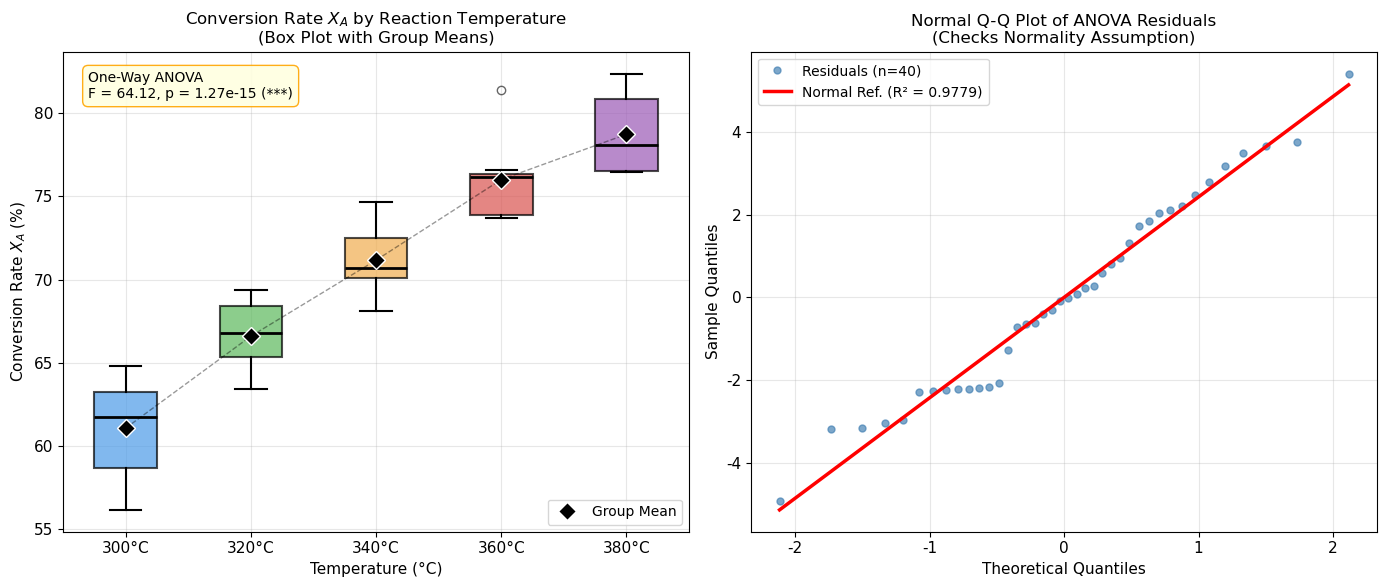

圖檔已儲存: d:\MyGit\ChemE-3502\Unit14\outputs\Unit14_Example_03\figs\anova_boxplot_qq.png

圖形說明:
  左圖: 各組箱體位置隨溫度遞增，均值連線呈現正相關趨勢；相鄰組別箱體有重疊。
  右圖: 殘差點大致沿參考直線分布，R² ≈ 0.978，殘差近似符合常態分布。


In [35]:
# ========================================
# 9. 視覺化分析
# ========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- 左圖：箱型圖 + 顯著差異標記 ----
ax1 = axes[0]
bp = ax1.boxplot(groups,
                 labels=[f'{T}°C' for T in temps],
                 patch_artist=True, notch=False,
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5),
                 boxprops=dict(linewidth=1.5),
                 flierprops=dict(marker='o', color='gray', alpha=0.6))

colors = ['#4C9BE8', '#5CB85C', '#F0AD4E', '#D9534F', '#9B59B6']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# 標記各組均值（鑽石形符號）
group_means = [np.mean(g) for g in groups]
ax1.plot(range(1, k+1), group_means, 'D', color='black',
         markersize=9, zorder=5, label='Group Mean', markeredgecolor='white')

# 連線顯示均值趨勢
ax1.plot(range(1, k+1), group_means, '--', color='black', alpha=0.4, linewidth=1)

# ANOVA 結果標注（p 值顯示科學記號）
sig_label = "***" if p_value < 0.001 else ("**" if p_value < 0.01 else ("*" if p_value < 0.05 else "ns"))
p_annot   = f"{p_value:.2e}" if p_value < 1e-4 else f"{p_value:.4f}"
ax1.annotate(f'One-Way ANOVA\nF = {F_stat:.2f}, p = {p_annot} ({sig_label})',
             xy=(0.04, 0.96), xycoords='axes fraction',
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                       edgecolor='orange', alpha=0.9))

ax1.set_title('Conversion Rate $X_A$ by Reaction Temperature\n(Box Plot with Group Means)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Conversion Rate $X_A$ (%)')
ax1.legend(loc='lower right')

# ---- 右圖：殘差常態 Q-Q 圖 ----
ax2 = axes[1]
residuals = np.concatenate([g - np.mean(g) for g in groups])
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')

ax2.plot(osm, osr, 'o', color='steelblue', alpha=0.7,
         markersize=5, label=f'Residuals (n={len(residuals)})')
ax2.plot(osm, slope * np.array(osm) + intercept,
         'r-', linewidth=2.5, label=f'Normal Ref. (R² = {r**2:.4f})')
ax2.set_title('Normal Q-Q Plot of ANOVA Residuals\n(Checks Normality Assumption)')
ax2.set_xlabel('Theoretical Quantiles')
ax2.set_ylabel('Sample Quantiles')
ax2.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'anova_boxplot_qq.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"圖檔已儲存: {FIG_DIR / 'anova_boxplot_qq.png'}")
print()
print("圖形說明:")
print("  左圖: 各組箱體位置隨溫度遞增，均值連線呈現正相關趨勢；相鄰組別箱體有重疊。")
print("  右圖: 殘差點大致沿參考直線分布，R² ≈ 0.978，殘差近似符合常態分布。")

---
### 10. 綜合結論

| 步驟 | 方法 | 結果摘要 | 結論 |
|------|------|----------|------|
| 1 | Shapiro-Wilk 常態性檢定 | 4 組通過，360°C 邊緣不通過 (p=0.033) | ANOVA 對輕度偏離常態具穩健性，可繼續分析 |
| 2 | Levene 變異數齊一性檢定 | p = 0.75 >> 0.05 | 各組變異數齊一，ANOVA 前提成立 ✓ |
| 3 | One-Way ANOVA (`f_oneway`) | F = 64.12, p ≈ 1.3×10⁻¹⁵ | 拒絕 H₀：溫度顯著影響轉化率 ✓ |
| 4 | 手動 ANOVA 表 | F 值與 scipy 結果一致 | 計算公式驗證正確 ✓ |
| 5 | Tukey HSD 多重比較 | 10 對中 9 對顯著差異；360°C vs 380°C 不顯著 (p-adj=0.22) | 相鄰高溫組別差異不夠大，但其餘組別均有顯著差異 |
| 6 | Kruskal-Wallis 無母數檢定 | H = 35.16, p ≈ 4.3×10⁻⁷ | 與 ANOVA 結論一致，強化推論可信度 ✓ |

**工程含義**：
- 反應溫度的提升對轉化率具有統計顯著的正向影響（F = 64.12, p ≈ 1.3×10⁻¹⁵）
- Tukey HSD 結果顯示：360°C 與 380°C 之間的轉化率差異不顯著（均值差 ≈ 2.7%，p-adj = 0.22），說明在高溫區段提升溫度的邊際效益遞減
- 在選擇最終操作溫度時，需在更高轉化率的效益與能耗、設備安全等成本之間尋求最佳平衡

---

**課程資訊**
- 課程名稱：電腦在化工上之應用 (ChemE 3502)
- 課程單元：Unit14 統計分析 — 單因子 ANOVA
- 課程製作：逢甲大學 化工系 智慧程序系統工程實驗室
- 授課教師：莊曜禎 助理教授
- 更新日期：2026-03-03

**課程授權 [CC BY-NC-SA 4.0]**
本教材遵循 [創用CC 姓名標示-非商業性-相同方式分享 4.0 國際 (CC BY-NC-SA 4.0)](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.zh) 授權。